In [1]:
# Ячейка 1: скомпилировать (один раз или при изменении .cpp)
!g++ -O3 -shared -fPIC -std=c++17 mendrive_core.cpp -o libmendrive.so

In [2]:
from mendrive_ctypes import lib, MenDriveCpp

In [3]:
sim = MenDriveCpp(N=80, ferrite_model='Preisach', bias_orientation='x', H0_bias=4.0,
                   n_sub=2, n_fp=2, n_newton=4, sigma_m_leak=3.0, sigma_e_left=3.0)
res = sim.run(omega0=7.45, n_periods=80, record_from_period=15, amp=1.0, ramp_periods=2.0)

In [4]:
res

{'t': array([12.651, 12.652, 12.653, ..., 67.468, 67.469, 67.47 ]),
 'dTxx': array([-0.00010916, -0.0001104 , -0.00011161, ..., -0.00010564,
        -0.00010695, -0.00010823]),
 'Hn': array([-0.02419941, -0.02541257, -0.02662432, ..., -0.02087173,
        -0.02208841, -0.02330386]),
 'Mn': array([[ 0.        , -0.89054726,  0.        ],
        [ 0.        , -0.89054726,  0.        ],
        [ 0.        , -0.89054726,  0.        ],
        ...,
        [ 0.        , -0.89054726,  0.        ],
        [ 0.        , -0.89054726,  0.        ],
        [ 0.        , -0.89054726,  0.        ]]),
 'HzJA': array([0., 0., 0., ..., 0., 0., 0.]),
 'MzJA': array([0., 0., 0., ..., 0., 0., 0.]),
 'P': array([-4.80121430e-04,  3.15535760e-04,  1.92228537e-03, ...,
         1.49193718e-03,  6.68171561e-05, -5.47155244e-04]),
 'Pdiss': array([0.00090473, 0.00090303, 0.00090195, ..., 0.00091249, 0.00090913,
        0.00090637]),
 'T': 0.843380578144911,
 'dt': 0.001,
 'blew_up': False}

In [5]:
sim = MenDriveCpp(N=80, ferrite_model='JA', bias_orientation='x', H0_bias=4.0,
                   n_sub=2, n_fp=2, n_newton=4, sigma_m_leak=3.0, sigma_e_left=3.0)
res = sim.run(omega0=7.45, n_periods=80, record_from_period=15, amp=1.0, ramp_periods=2.0)

In [6]:
res

{'t': array([12.651, 12.652, 12.653, ..., 67.468, 67.469, 67.47 ]),
 'dTxx': array([ 0.25047489,  0.24375333,  0.23590253, ..., -0.01603679,
        -0.01885811, -0.02153936]),
 'Hn': array([ 1.96779341,  1.90084171,  1.84240003, ..., -1.06064528,
        -1.09892992, -1.13663486]),
 'Mn': array([[ 0.        ,  0.84750063,  0.        ],
        [ 0.        ,  0.84586508,  0.        ],
        [ 0.        ,  0.84322628,  0.        ],
        ...,
        [ 0.        , -0.6751962 ,  0.        ],
        [ 0.        , -0.687446  ,  0.        ],
        [ 0.        , -0.69875451,  0.        ]]),
 'HzJA': array([0., 0., 0., ..., 0., 0., 0.]),
 'MzJA': array([0., 0., 0., ..., 0., 0., 0.]),
 'P': array([ 0.10920782, -0.04291807, -0.18114664, ..., -0.65725486,
        -0.4527869 , -0.2619397 ]),
 'Pdiss': array([0.30741154, 0.30326481, 0.30389727, ..., 0.29975738, 0.29476618,
        0.29160956]),
 'T': 0.843380578144911,
 'dt': 0.001,
 'blew_up': False}

In [7]:
# Ячейка: перенесённая логика main() -- скан, FFT, сходимость, гистерезис, сравнение
import numpy as np
import matplotlib.pyplot as plt
import time, os

def shoelace_area(x, y):
    """Площадь замкнутой кривой (проверка петли гистерезиса)."""
    return 0.5*abs(np.sum(x*np.roll(y,-1) - np.roll(x,-1)*y))

def scan_resonance_cpp(N, freqs, ferrite_model='JA', n_sub=1, n_fp=1, n_newton=3, **kwargs):
    resp = []
    for w in freqs:
        sim = MenDriveCpp(N, ferrite_model=ferrite_model, n_sub=n_sub, n_fp=n_fp, n_newton=n_newton, **kwargs)
        res = sim.run(w, n_periods=3, record_from_period=1, amp=0.3, ramp_periods=1)
        a_resp = (res['Hn'].max()-res['Hn'].min())/2 if (len(res['Hn'])>0 and not res['blew_up']) else np.nan
        resp.append(a_resp)
    return np.array(resp)

def main_cpp(N=20, ferrite_model='Preisach', bias_orientation='x', H0_bias=4.0,
             excitation_mode='magnetic_right', sigma_e_left=3.0, sigma_m_leak=3.0,
             Ms=1.0, a_JA=0.3, alpha_JA=0.001, k_JA=0.15, c_JA=0.15,
             Ms_llg=0.3, gamma_llg=1.0, alpha_llg=0.1,
             n_sub=2, n_fp=2, n_newton=4,
             freqs_wide=None, freqs_fine_halfwidth=0.9, freqs_fine_step=0.1,
             n_periods_total=80, record_from_period=15, amp=1.0, ramp_periods=2.0,
             probe_idx=0, last_frac_force=0.5,
             make_plots=True, out_dir='./outputs', show_plots=True, verbose=True):
    """Полный порт main() на C++ ядро вместо чистого Python. См. docstring
    в предыдущем ответе для подробного описания шагов и возвращаемых ключей."""
    os.makedirs(out_dir, exist_ok=True)
    t_start = time.time()
    common_kwargs = dict(bias_orientation=bias_orientation, H0_bias=H0_bias,
                          Ms_llg=Ms_llg, gamma_llg=gamma_llg, alpha_llg=alpha_llg,
                          Ms=Ms, a_JA=a_JA, alpha_JA=alpha_JA, k_JA=k_JA, c_JA=c_JA,
                          sigma_m_leak=sigma_m_leak, sigma_e_left=sigma_e_left,
                          excitation_mode=excitation_mode)
    plots = []

    if freqs_wide is None:
        freqs_wide = np.arange(1.0, 16.01, 0.5)
    resp_wide = scan_resonance_cpp(N, freqs_wide, ferrite_model=ferrite_model,
                                    n_sub=1, n_fp=1, n_newton=3, **common_kwargs)
    omega_coarse = freqs_wide[np.nanargmax(resp_wide)]
    if verbose:
        print(f"[main_cpp] Грубый скан: пик omega0~{omega_coarse:.2f}, {time.time()-t_start:.2f}с")

    lo = max(freqs_wide[0], omega_coarse - freqs_fine_halfwidth)
    hi = omega_coarse + freqs_fine_halfwidth
    freqs_fine = np.arange(lo, hi + 1e-9, freqs_fine_step)
    resp_fine = scan_resonance_cpp(N, freqs_fine, ferrite_model=ferrite_model,
                                    n_sub=1, n_fp=1, n_newton=3, **common_kwargs)
    omega_res = freqs_fine[np.nanargmax(resp_fine)] if not np.all(np.isnan(resp_fine)) else omega_coarse
    if verbose:
        print(f"[main_cpp] Уточнённый резонанс: omega0={omega_res:.3f}, {time.time()-t_start:.2f}с")

    if make_plots:
        plt.figure(figsize=(8,4))
        plt.plot(freqs_wide, resp_wide, 'o--', ms=3, alpha=0.5, label='грубый скан')
        plt.plot(freqs_fine, resp_fine, 'o-', ms=4, color='tab:blue', label='уточняющий скан')
        plt.axvline(omega_res, color='red', ls='--', label=f'omega0={omega_res:.2f}')
        plt.xlabel('omega0'); plt.ylabel('амплитуда отклика Hz')
        plt.title(f'{ferrite_model} (C++): скан резонанса')
        plt.legend(); plt.grid(True); plt.tight_layout()
        p = os.path.join(out_dir, f'scan_{ferrite_model}_cpp.png')
        plt.savefig(p, dpi=120);
        if show_plots:
            plt.show();
        plt.close(); plots.append(p)

    sim = MenDriveCpp(N, ferrite_model=ferrite_model, n_sub=n_sub, n_fp=n_fp,
                       n_newton=n_newton, **common_kwargs)
    res_long = sim.run(omega_res, n_periods=n_periods_total,
                        record_from_period=record_from_period, amp=amp,
                        ramp_periods=ramp_periods, probe_idx=probe_idx)
    if verbose:
        n_cov = len(res_long['t'])*res_long['dt']/res_long['T'] if len(res_long['t'])>0 else 0.0
        print(f"[main_cpp] Длинный прогон: {time.time()-t_start:.2f}с, точек={len(res_long['t'])}, "
              f"blew_up={res_long['blew_up']}, периодов записи~{n_cov:.1f}")

    res_llg_ref = None
    if ferrite_model == 'Hybrid':
        llg_kwargs = dict(bias_orientation=bias_orientation, H0_bias=H0_bias,
                           Ms_llg=Ms_llg, gamma_llg=gamma_llg, alpha_llg=alpha_llg,
                           sigma_e_left=sigma_e_left, excitation_mode=excitation_mode)
        sim_llg = MenDriveCpp(N, ferrite_model='LLG', **llg_kwargs)
        res_llg_ref = sim_llg.run(omega_res, n_periods=n_periods_total,
                                   record_from_period=record_from_period, amp=amp,
                                   ramp_periods=ramp_periods, probe_idx=probe_idx)

    t_h, dTxx_h, dt_h, T_h = res_long['t'], res_long['dTxx'], res_long['dt'], res_long['T']
    fft_freqs, fft_mag = np.array([]), np.array([])
    if len(dTxx_h) >= 8:
        Nfft = len(dTxx_h)
        window = np.hanning(Nfft)
        spec = np.fft.rfft(dTxx_h * window)
        fft_freqs = np.fft.rfftfreq(Nfft, d=dt_h) * 2*np.pi
        fft_mag = np.abs(spec)
        if make_plots:
            plt.figure(figsize=(9,4))
            plt.plot(fft_freqs, fft_mag, lw=1.0)
            plt.axvline(omega_res, color='red', ls='--', alpha=0.6, label=f'omega0={omega_res:.2f}')
            if bias_orientation in ('x','y','z') and ferrite_model in ('LLG','Hybrid'):
                plt.axvline(gamma_llg*H0_bias, color='green', ls='--', alpha=0.6,
                            label=f'gamma*H0={gamma_llg*H0_bias:.2f}')
            plt.xlim(0, min(fft_freqs.max(), 4*omega_res))
            plt.xlabel('omega'); plt.ylabel('|FFT(dTxx)|')
            plt.title(f'{ferrite_model} (C++): спектр dTxx')
            plt.legend(); plt.grid(True); plt.tight_layout()
            p = os.path.join(out_dir, f'fft_dTxx_{ferrite_model}_cpp.png')
            plt.savefig(p, dpi=120);
            if show_plots:
                plt.show();
            plt.close(); plots.append(p)

    convergence_ratio_cum = np.array([])
    spp_h = int(round(T_h/dt_h)) if len(t_h) > 0 else 0
    if spp_h > 0:
        n_rec_periods = len(t_h) // spp_h
        if n_rec_periods >= 1:
            pm_dTxx = np.array([dTxx_h[i*spp_h:(i+1)*spp_h].mean() for i in range(n_rec_periods)])
            pm_P = np.array([res_long['P'][i*spp_h:(i+1)*spp_h].mean() for i in range(n_rec_periods)])
            cum_F = np.cumsum(pm_dTxx) / np.arange(1, n_rec_periods+1)
            cum_P = np.cumsum(pm_P) / np.arange(1, n_rec_periods+1)
            convergence_ratio_cum = np.where(np.abs(cum_P) > 1e-30, cum_F/cum_P, np.nan)
            if make_plots:
                plt.figure(figsize=(9,4))
                plt.plot(np.arange(1, n_rec_periods+1), convergence_ratio_cum, 'o-', ms=3)
                plt.xlabel('периодов усреднено'); plt.ylabel('накопл. среднее dTxx/P')
                plt.title(f'{ferrite_model} (C++): сходимость force/power')
                plt.grid(True); plt.tight_layout()
                p = os.path.join(out_dir, f'convergence_{ferrite_model}_cpp.png')
                plt.savefig(p, dpi=120);
                if show_plots:
                    plt.show();
                plt.close(); plots.append(p)

    hysteresis_area = None
    if ferrite_model == 'Hybrid' and spp_h > 0 and len(res_long['HzJA']) >= spp_h:
        Hloop = res_long['HzJA'][-spp_h:]
        Bloop = Hloop + 4*np.pi*res_long['MzJA'][-spp_h:]
        hysteresis_area = shoelace_area(Hloop, Bloop)
        if make_plots:
            plt.figure(figsize=(8,8))
            plt.plot(Hloop, Bloop, lw=1.5, color='tab:green', marker='o', ms=2)
            plt.xlabel('H (Э)'); plt.ylabel('B (Гс)')
            plt.title(f'Hybrid: внутренняя петля JA (площадь={hysteresis_area:.3e})')
            plt.grid(True); plt.tight_layout()
            p = os.path.join(out_dir, 'hysteresis_Hybrid_internalJA_cpp.png')
            plt.savefig(p, dpi=120);
            if show_plots:
                plt.show();
            plt.close(); plots.append(p)
    elif ferrite_model in ['JA', 'Preisach'] and spp_h > 0:
        Hloop = res_long['Hn'][-spp_h:]
        Bloop = Hloop + 4*np.pi*res_long['Mn'][-spp_h:, 1]
        hysteresis_area = shoelace_area(Hloop, Bloop)
        if make_plots:
            plt.figure(figsize=(8,8))
            plt.plot(Hloop, Bloop, lw=1.5, color='tab:purple', marker='o', ms=2)
            plt.xlabel('H (Э)'); plt.ylabel('B (Гс)')
            plt.title(f'{ferrite_model}: петля гистерезиса (площадь={hysteresis_area:.3e})')
            plt.grid(True); plt.tight_layout()
            p = os.path.join(out_dir, f'hysteresis_{ferrite_model}_cpp.png')
            plt.savefig(p, dpi=120);
            if show_plots:
                plt.show();
            plt.close(); plots.append(p)

    if ferrite_model == 'Hybrid' and res_llg_ref is not None and spp_h > 0:
        n_traj = min(3*spp_h, len(res_long['Mn']), len(res_llg_ref['Mn']))
        if n_traj > 0:
            fig, axes = plt.subplots(1, 2, figsize=(11,5))
            axes[0].plot(res_long['Mn'][-n_traj:,1], res_long['Mn'][-n_traj:,2], lw=0.8, color='tab:green')
            axes[0].set_title('Hybrid: траектория M'); axes[0].set_aspect('equal'); axes[0].grid(True)
            axes[1].plot(res_llg_ref['Mn'][-n_traj:,1], res_llg_ref['Mn'][-n_traj:,2], lw=0.8, color='tab:orange')
            axes[1].set_title('Чистый LLG: траектория M'); axes[1].set_aspect('equal'); axes[1].grid(True)
            plt.tight_layout()
            p = os.path.join(out_dir, 'M_trajectory_Hybrid_vs_LLG_cpp.png')
            plt.savefig(p, dpi=120);
            if show_plots:
                plt.show();
            plt.close(); plots.append(p)

    force_per_power_code, force_per_kW = sim.force_per_power(res_long, last_frac=last_frac_force)
    if verbose:
        print(f"[main_cpp] FORCE/POWER: {force_per_power_code:.4e} (код.ед.), {force_per_kW:.4e} Н/кВт")
        print(f"[main_cpp] Итого времени: {time.time()-t_start:.2f}с")

    return dict(omega_res=omega_res, freqs_wide=freqs_wide, resp_wide=resp_wide,
                freqs_fine=freqs_fine, resp_fine=resp_fine,
                res_long=res_long, res_long_llg_ref=res_llg_ref,
                hysteresis_area=hysteresis_area, fft_freqs=fft_freqs, fft_mag=fft_mag,
                convergence_ratio_cum=convergence_ratio_cum,
                force_per_power_code=force_per_power_code, force_per_kW=force_per_kW, plots=plots)

[main_cpp] Грубый скан: пик omega0~7.50, 17.44с
[main_cpp] Уточнённый резонанс: omega0=7.500, 24.71с


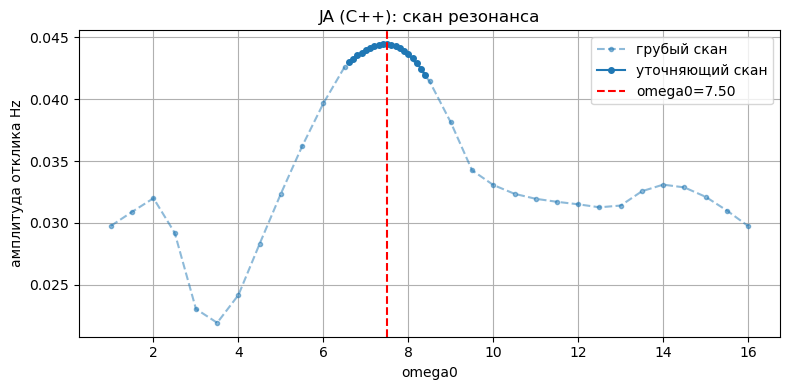

[main_cpp] Длинный прогон: 3076.56с, точек=5864306, blew_up=False, периодов записи~7000.0


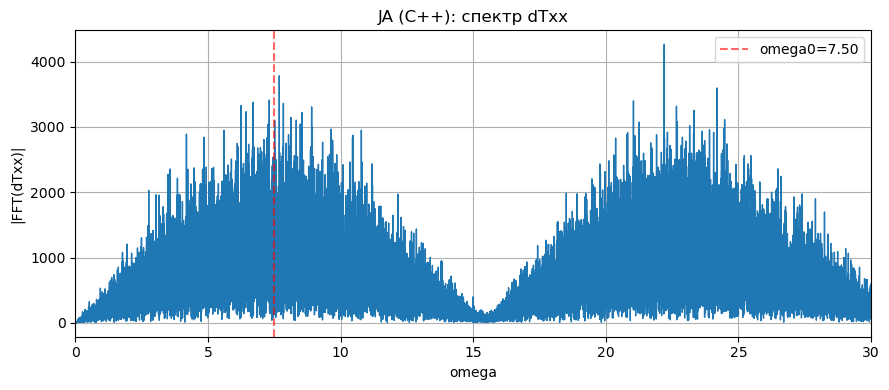

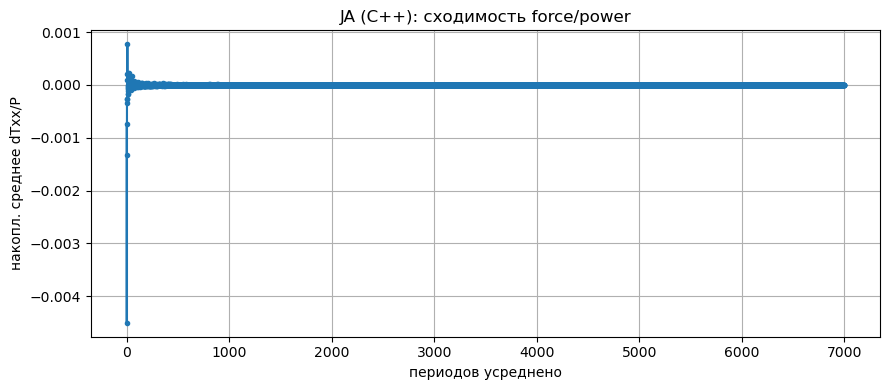

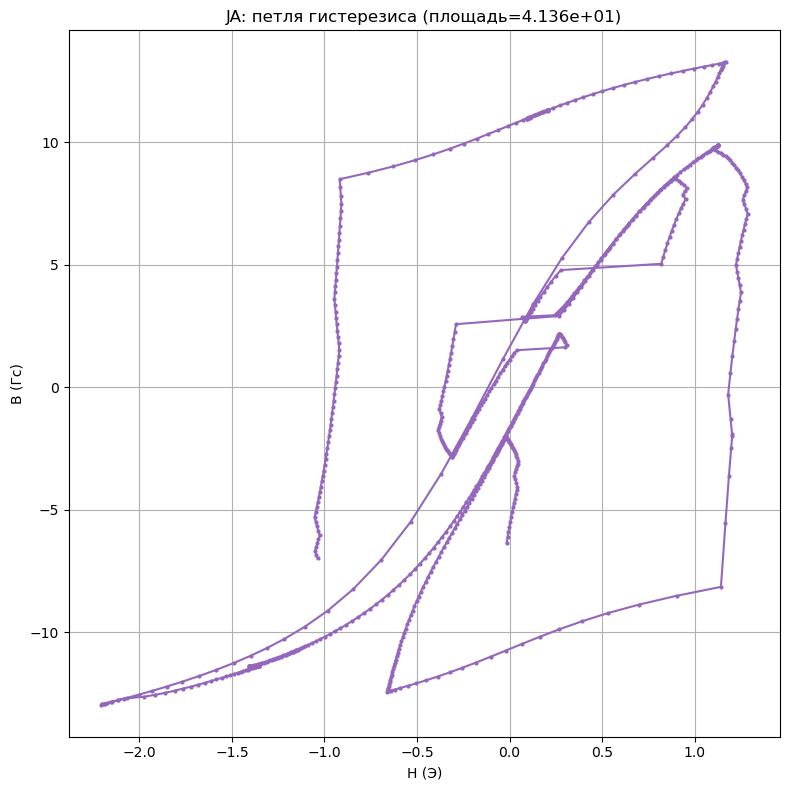

[main_cpp] FORCE/POWER: -8.7260e-07 (код.ед.), -8.7260e-02 Н/кВт
[main_cpp] Итого времени: 3079.69с
omega_res = 7.4999999999999964
force_per_kW = -0.08726037176580105
hysteresis_area = 41.35844620359576


In [8]:
result = main_cpp(N=80, ferrite_model='JA', bias_orientation='x', H0_bias=4.0,
                   n_sub=2, n_fp=2, n_newton=4, sigma_m_leak=3.0, sigma_e_left=3.0,
                   n_periods_total=8000, record_from_period=1000)
print("omega_res =", result['omega_res'])
print("force_per_kW =", result['force_per_kW'])
print("hysteresis_area =", result['hysteresis_area'])

[main_cpp] Грубый скан: пик omega0~8.00, 17.65с
[main_cpp] Уточнённый резонанс: omega0=7.900, 24.54с


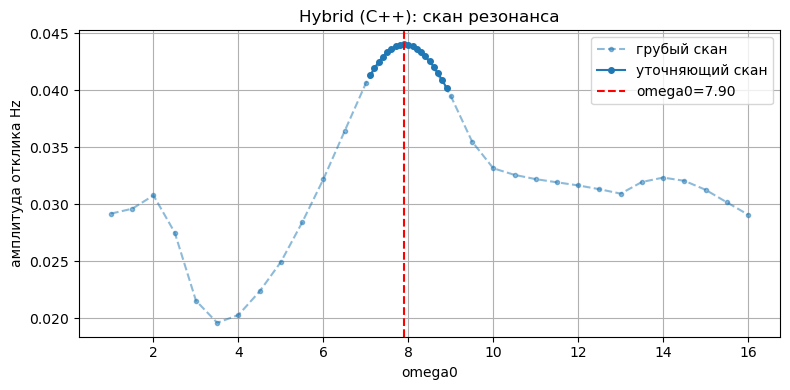

[main_cpp] Длинный прогон: 2924.45с, точек=5567380, blew_up=False, периодов записи~7000.0


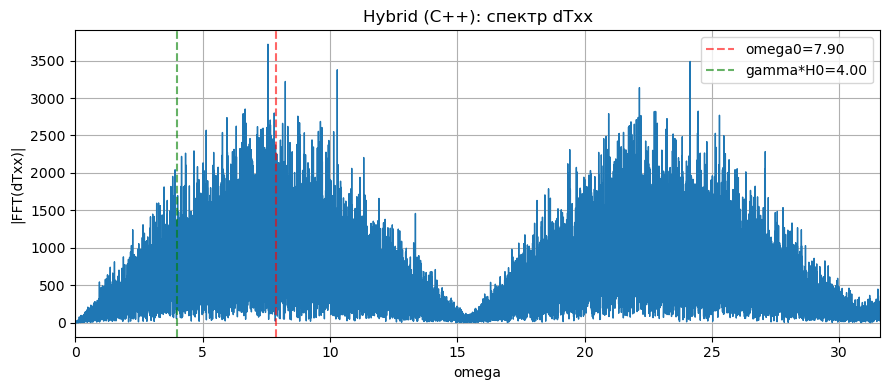

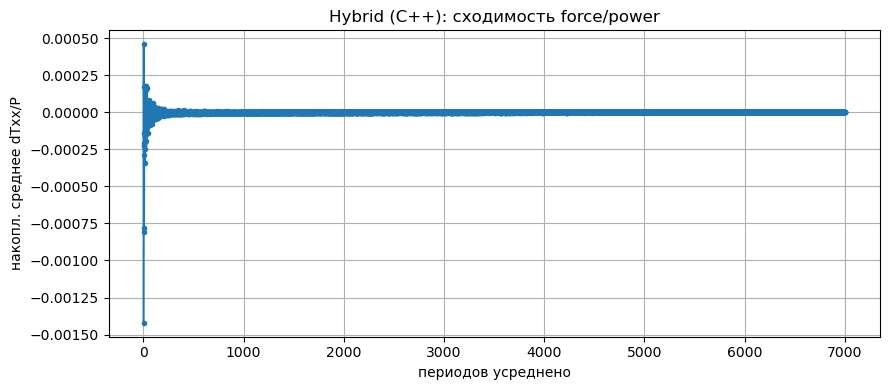

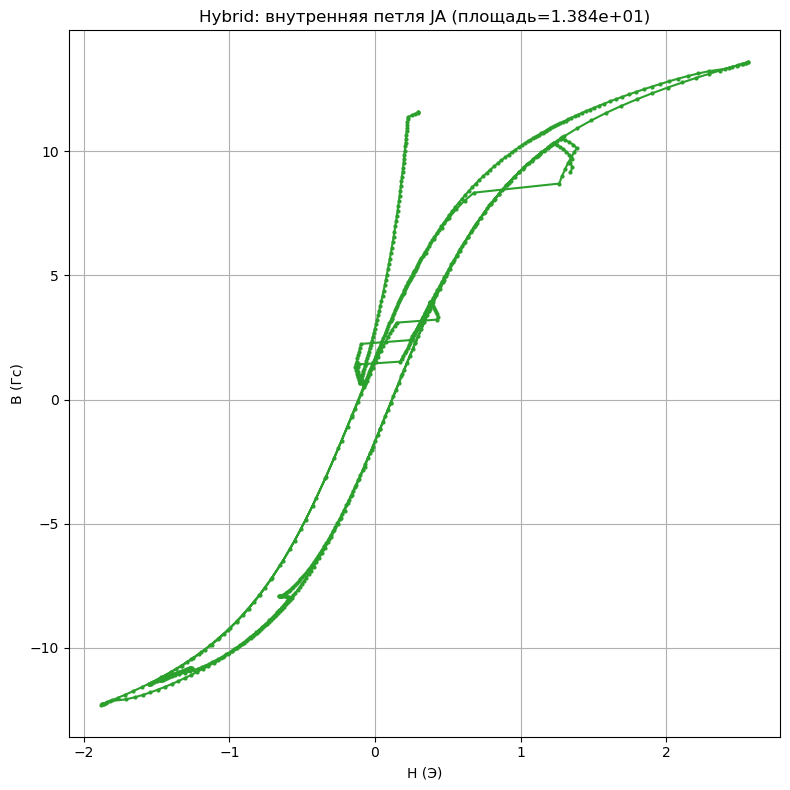

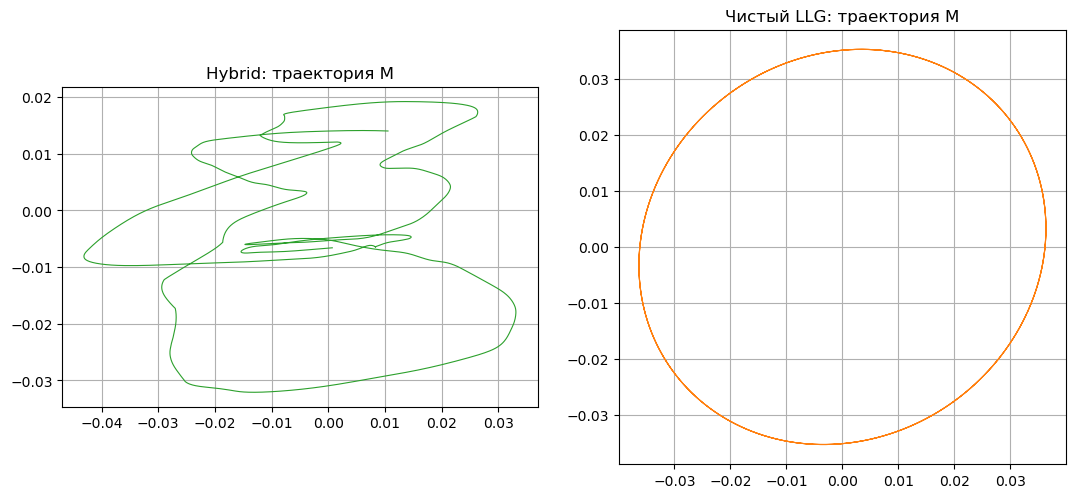

[main_cpp] FORCE/POWER: 7.2322e-07 (код.ед.), 7.2322e-02 Н/кВт
[main_cpp] Итого времени: 2953.67с
omega_res = 7.899999999999997
force_per_kW = 0.07232151726239311
hysteresis_area = 13.837102753918604


In [9]:
result = main_cpp(N=80, ferrite_model='Hybrid', bias_orientation='x', H0_bias=4.0,
                   n_sub=2, n_fp=2, n_newton=4, sigma_m_leak=3.0, sigma_e_left=3.0,
                   n_periods_total=8000, record_from_period=1000)
print("omega_res =", result['omega_res'])
print("force_per_kW =", result['force_per_kW'])
print("hysteresis_area =", result['hysteresis_area'])

[main_cpp] Грубый скан: пик omega0~7.50, 4.05с
[main_cpp] Уточнённый резонанс: omega0=7.500, 5.74с


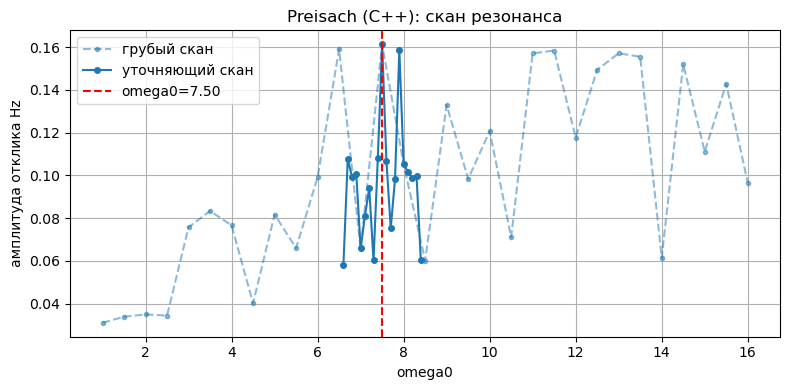

[main_cpp] Длинный прогон: 294.83с, точек=5864306, blew_up=False, периодов записи~7000.0


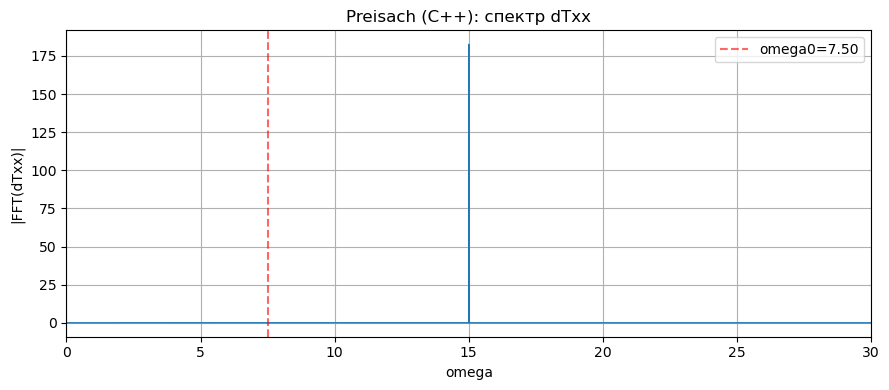

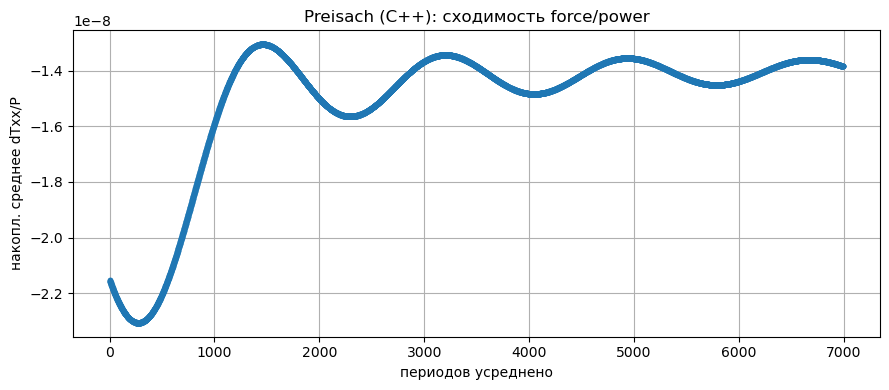

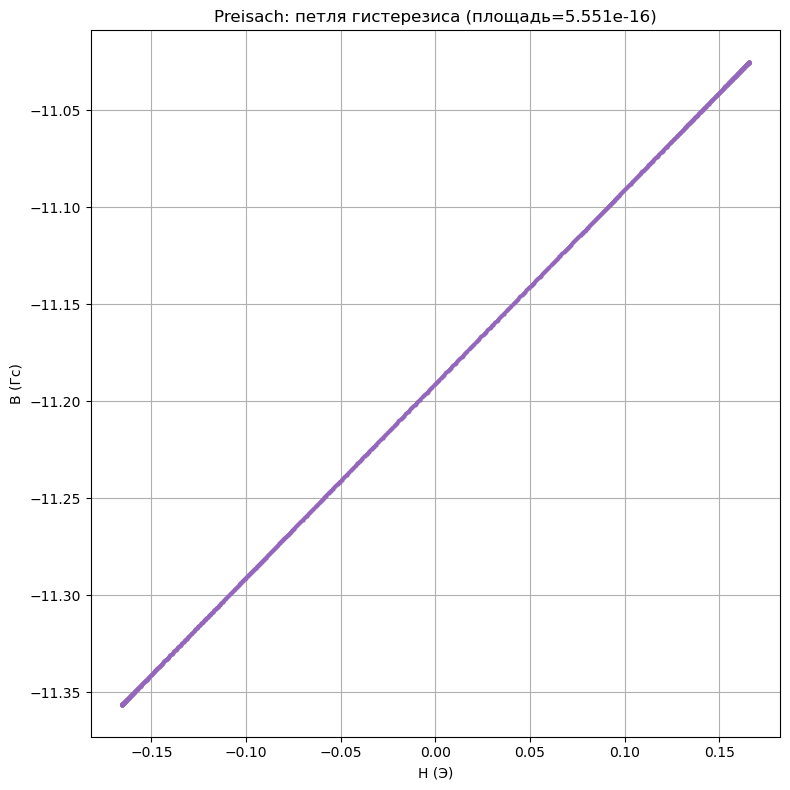

[main_cpp] FORCE/POWER: -1.3837e-08 (код.ед.), -1.3837e-03 Н/кВт
[main_cpp] Итого времени: 297.87с
omega_res = 7.4999999999999964
force_per_kW = -0.0013836671229625719
hysteresis_area = 5.551115123125783e-16


In [10]:
result = main_cpp(N=80, ferrite_model='Preisach', bias_orientation='x', H0_bias=4.0,
                   n_sub=2, n_fp=2, n_newton=4, sigma_m_leak=3.0, sigma_e_left=3.0,
                   n_periods_total=8000, record_from_period=1000)
print("omega_res =", result['omega_res'])
print("force_per_kW =", result['force_per_kW'])
print("hysteresis_area =", result['hysteresis_area'])

[main_cpp] Грубый скан: пик omega0~16.00, 4.03с
[main_cpp] Уточнённый резонанс: omega0=16.900, 4.83с


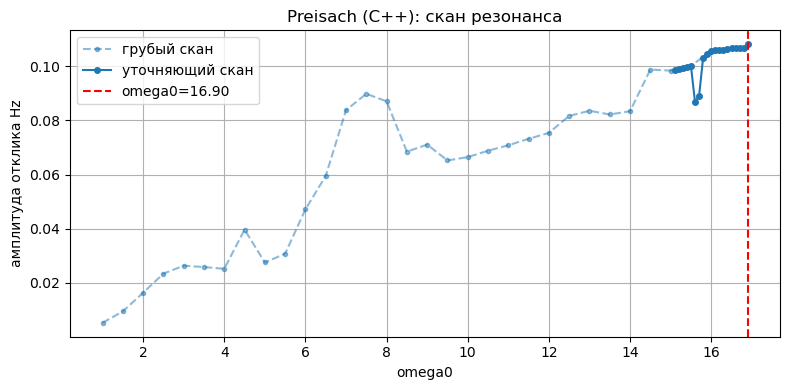

[main_cpp] Длинный прогон: 133.23с, точек=2602502, blew_up=False, периодов записи~7000.0


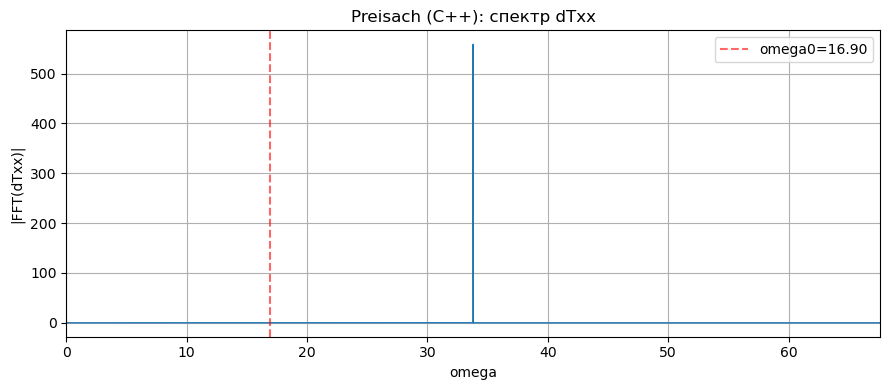

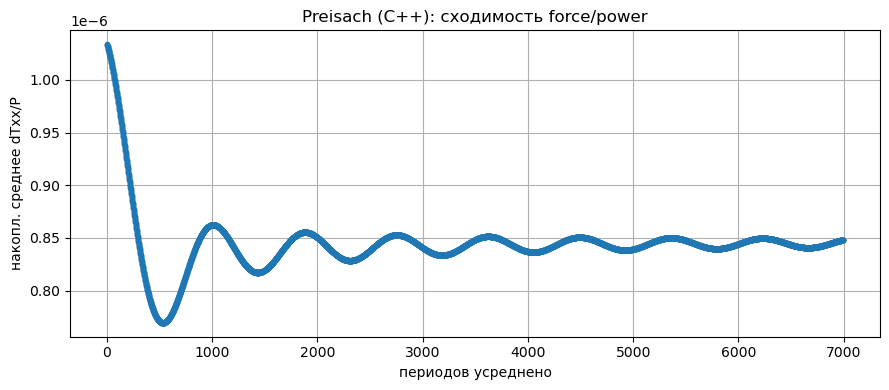

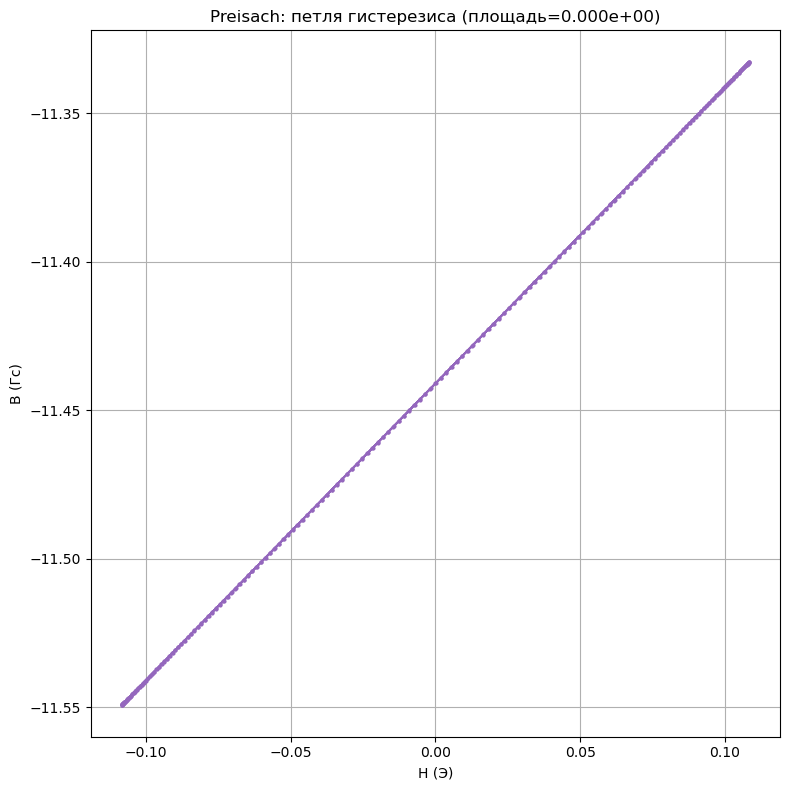

[main_cpp] FORCE/POWER: 8.4839e-07 (код.ед.), 8.4839e-02 Н/кВт
[main_cpp] Итого времени: 134.79с
omega_res = 16.89999999999999
force_per_kW = 0.08483887994931967
hysteresis_area = 0.0


In [11]:
result = main_cpp(N=80, excitation_mode='electric_left', ferrite_model='Preisach', bias_orientation='x', H0_bias=4.0,
                   n_sub=2, n_fp=2, n_newton=4, sigma_m_leak=3.0, sigma_e_left=3.0,
                   n_periods_total=8000, record_from_period=1000)
print("omega_res =", result['omega_res'])
print("force_per_kW =", result['force_per_kW'])
print("hysteresis_area =", result['hysteresis_area'])